In [4]:
# Run this, then RESTART SESSION (Runtime > Restart session)
!pip install -U --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q "transformers==4.37.2" "adapters==0.1.1" "datasets" "evaluate" "accelerate"

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 146.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 124.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 111.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 146.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 22.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 48.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.4 MB/s eta 0:00:00
ERROR: Cannot install adapters==0.1.1 and transformers==4.37.2 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


Mounted at /content/drive
Loading datasets...


Map:   0%|          | 0/23547 [00:00<?, ? examples/s]


--- Evaluating Pre-trained Baseline ---


Baseline PPL: 48.90

>>> Running: 0% Replay


Step,Training Loss,Validation Loss
625,2.774700,4.501731
1250,2.710100,4.499280



>>> Running: 10% Replay


Step,Training Loss,Validation Loss
694,2.845300,3.672758
1388,2.826200,3.619196



>>> Running: 20% Replay


Step,Training Loss,Validation Loss
781,3.201000,3.554039
1562,2.913300,3.474059


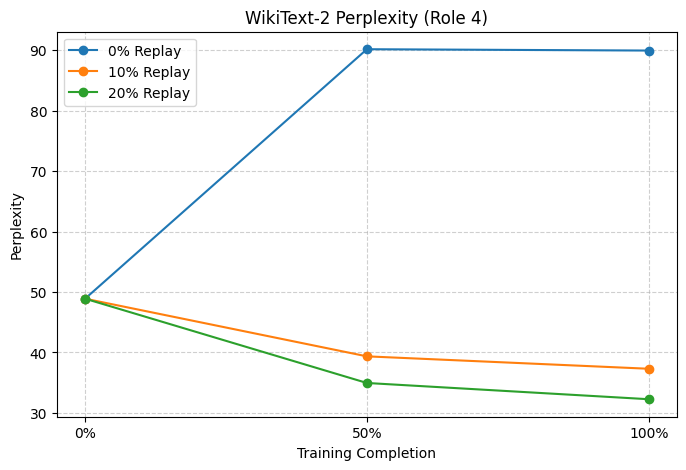

Execution complete. Files saved to Drive.


In [2]:
# ==============================================================================
# 1. MOUNT DRIVE & SETUP
# ==============================================================================
from google.colab import drive
import os, math, csv, torch
import matplotlib.pyplot as plt

drive.mount('/content/drive', force_remount=True)
PROJECT_DIR = "/content/drive/MyDrive/NLP_Project_Role4"
os.makedirs(PROJECT_DIR, exist_ok=True)

import transformers
import adapters
from datasets import load_dataset, concatenate_datasets
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, DataCollatorForLanguageModeling
from adapters import AdapterTrainer

# ==============================================================================
# 2. CONFIG & DATA
# ==============================================================================
MODEL_NAME = "gpt2-medium"
MAX_SEQ_LENGTH = 128
REPLAY_RATIOS = [0.0, 0.1, 0.2]
EPOCHS = 1
BATCH_SIZE = 4
SEED = 42

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

print("Loading datasets...")
sst2_train = load_dataset("glue", "sst2", split="train")
wiki_train = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
wiki_test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

def format_sst2(example):
    text = f"Review: {example['sentence'].strip()}\nSentiment: {'Positive' if example['label'] == 1 else 'Negative'}{tokenizer.eos_token}"
    return tokenizer(text, truncation=True, max_length=MAX_SEQ_LENGTH)

def format_wiki(example):
    text = f"{example['text'].strip()}{tokenizer.eos_token}"
    return tokenizer(text, truncation=True, max_length=MAX_SEQ_LENGTH)

tokenized_sst2 = sst2_train.map(format_sst2, remove_columns=sst2_train.column_names)
tokenized_wiki_train = wiki_train.filter(lambda x: len(x['text'].strip()) > 10).map(format_wiki, remove_columns=wiki_train.column_names)
tokenized_wiki_test = wiki_test.filter(lambda x: len(x['text'].strip()) > 10).map(format_wiki, remove_columns=wiki_test.column_names)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# ==============================================================================
# 3. EXPERIMENT LOOP
# ==============================================================================
results = {}

# Baseline Evaluation
print("\n--- Evaluating Pre-trained Baseline ---")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
# Note: Use a dummy TrainingArguments for evaluation
eval_args = TrainingArguments(output_dir="./temp", report_to="none")
baseline_trainer = AdapterTrainer(model=model, args=eval_args, eval_dataset=tokenized_wiki_test, data_collator=data_collator)
base_ppl = math.exp(baseline_trainer.evaluate()["eval_loss"])
print(f"Baseline PPL: {base_ppl:.2f}")
del model
torch.cuda.empty_cache()

for ratio in REPLAY_RATIOS:
    label = f"{int(ratio*100)}% Replay"
    print(f"\n>>> Running: {label}")

    # Mix Data - Using a smaller subset (5000) for faster Week 1 validation
    sst2_subset = tokenized_sst2.shuffle(seed=SEED).select(range(5000))
    if ratio > 0.0:
        count = int((ratio * len(sst2_subset)) / (1 - ratio))
        wiki_subset = tokenized_wiki_train.shuffle(seed=SEED).select(range(min(count, len(tokenized_wiki_train))))
        train_ds = concatenate_datasets([sst2_subset, wiki_subset]).shuffle(seed=SEED)
    else:
        train_ds = sst2_subset

    # Adapter Setup
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
    adapters.init(model)

    adapter_name = f"replay_{int(ratio*100)}"
    model.add_adapter(adapter_name, config="seq_bn")
    model.set_active_adapters(adapter_name) # Activating adapter for forward pass
    model.train_adapter(adapter_name)

    # Correcting the argument names for the newest Transformers version
    mid_step = (len(train_ds) // BATCH_SIZE) // 2

    trainer = AdapterTrainer(
        model=model,
        args=TrainingArguments(
            output_dir=f"{PROJECT_DIR}/logs_{int(ratio*100)}",
            learning_rate=1e-4,
            num_train_epochs=EPOCHS,
            per_device_train_batch_size=BATCH_SIZE,
            eval_strategy="steps",        # CHANGED: 'evaluation_strategy' -> 'eval_strategy'
            eval_steps=mid_step,
            save_strategy="steps",        # Added explicit save strategy
            save_steps=mid_step,
            save_total_limit=1,
            logging_steps=50,
            report_to="none"
        ),
        train_dataset=train_ds,
        eval_dataset=tokenized_wiki_test,
        data_collator=data_collator,
    )

    trainer.train()

    # Log Results
    eval_logs = [log for log in trainer.state.log_history if "eval_loss" in log]
    mid_ppl = math.exp(eval_logs[0]["eval_loss"]) if eval_logs else base_ppl
    final_ppl = math.exp(trainer.evaluate()["eval_loss"])

    results[label] = [base_ppl, mid_ppl, final_ppl]

    # Cleanup
    del model, trainer
    torch.cuda.empty_cache()

# ==============================================================================
# 4. EXPORT & PLOT
# ==============================================================================
with open(f"{PROJECT_DIR}/results.csv", 'w') as f:
    w = csv.writer(f)
    w.writerow(["Config", "0%", "50%", "100%"])
    for k, v in results.items(): w.writerow([k] + [f"{x:.2f}" for x in v])

plt.figure(figsize=(8, 5))
for k, v in results.items(): plt.plot(["0%", "50%", "100%"], v, marker='o', label=k)
plt.title("WikiText-2 Perplexity (Role 4)")
plt.ylabel("Perplexity")
plt.xlabel("Training Completion")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(f"{PROJECT_DIR}/plot.png")
plt.show()

print(f"Execution complete. Files saved to Drive.")